# ДЗ №2. Задача регресси с использованием полносвязной НС

Вам предлагается разработать алгоритмы машинного обучения, которые позволяют установить связь между химическим составом, различными свойствами сверхпроводниками и их критической температурой.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [105]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Датасет с признаками train и датасет с формулами formula_train:

In [106]:
train = pd.read_csv('train.csv')
formula_train = pd.read_csv('formula_train.csv')

train.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [107]:
missing_counts_1 = train.isna().sum()
print(missing_counts_1[missing_counts_1 > 0])

Series([], dtype: int64)


In [108]:
missing_counts_2 = formula_train.isna().sum()
print(missing_counts_2[missing_counts_2 > 0])

Series([], dtype: int64)


In [109]:
# Объединяем данные
formula_train = formula_train.drop(columns=['critical_temp'])
train_full = pd.concat([train, formula_train], axis=1)

train_full.drop(columns=['material'], inplace=True)

train_full.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


### Информация о целевой переменной

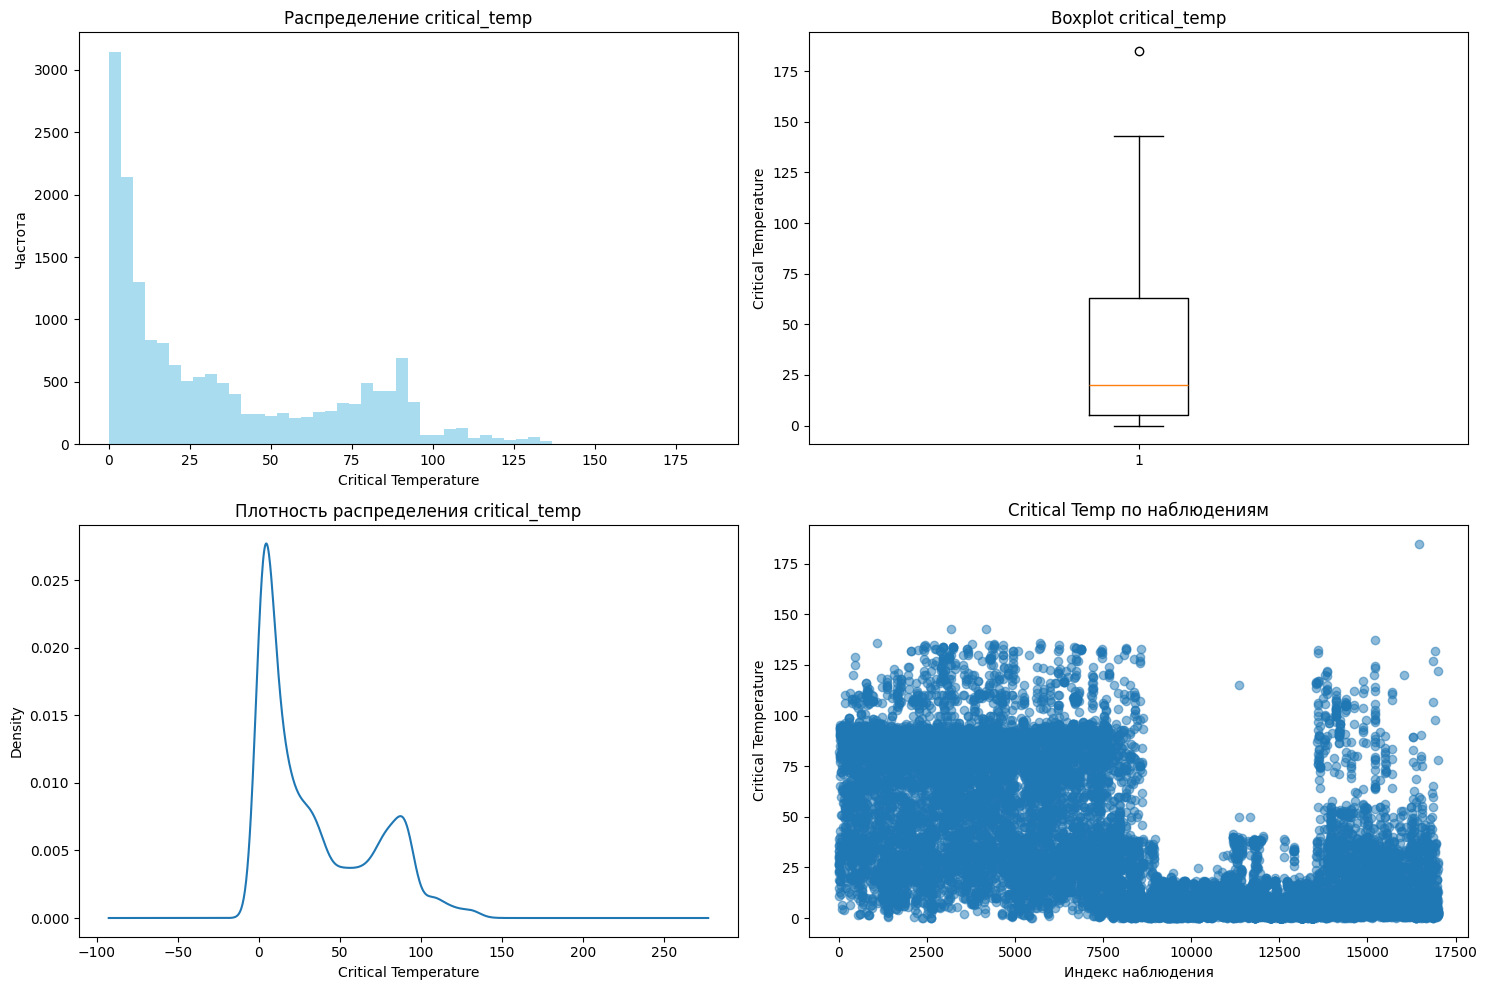

count    17010.000000
mean        34.502993
std         34.334793
min          0.000210
25%          5.330000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64


In [110]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# гистограмма
axes[0,0].hist(train['critical_temp'], bins=50, alpha=0.7, color='skyblue')
axes[0,0].set_title('Распределение critical_temp')
axes[0,0].set_xlabel('Critical Temperature')
axes[0,0].set_ylabel('Частота')

# boxplot
axes[0,1].boxplot(train['critical_temp'])
axes[0,1].set_title('Boxplot critical_temp')
axes[0,1].set_ylabel('Critical Temperature')

# плотность распределения
train['critical_temp'].plot.kde(ax=axes[1,0])
axes[1,0].set_title('Плотность распределения critical_temp')
axes[1,0].set_xlabel('Critical Temperature')

# точечный график (по индексу)
axes[1,1].scatter(range(len(train)), train['critical_temp'], alpha=0.5)
axes[1,1].set_title('Critical Temp по наблюдениям')
axes[1,1].set_xlabel('Индекс наблюдения')
axes[1,1].set_ylabel('Critical Temperature')

plt.tight_layout()
plt.show()

# базовая статистика
print(train['critical_temp'].describe())

In [111]:
# Рассмотрим выброс
outliers = train[train['critical_temp'] > 175]
print(outliers[['critical_temp']])

       critical_temp
16461          185.0


In [112]:
train_full = train_full.drop(train_full.index[16460])

In [113]:
# Выделим из набора данных вектор признаков и вектор ответов
y = train_full['critical_temp'].values
X = train_full.drop(columns=['critical_temp'])
X = X.values.astype(np.float32)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (17009, 167)
Target shape: (17009,)


### Создаём НС

In [114]:
# Разделяем на train и validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Train dataset size: {X_val.shape}, {y_val.shape}')

Train dataset size: (13607, 167), (13607,)
Train dataset size: (3402, 167), (3402,)


In [124]:
# Масштабируем признаки
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val = scaler_y.transform(y_val.reshape(-1, 1)).flatten()

In [116]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

In [117]:
class Neuron(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

In [118]:
# Инициализация модели
model = Neuron(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [119]:
# Обучение модели
num_epochs = 160
best_loss = float('inf')
patience = 15
counter = 0

for epoch in range(num_epochs):
    model.train()
    y_pred = model(X_train)
    train_loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        test_loss = criterion(y_val_pred, y_val)

    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping на эпохе {epoch+1}')
            break

    if (epoch + 1) % 20 == 0:
        print(f'Эпоха {epoch+1}, Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

Эпоха 20, Train Loss: 0.2850, Test Loss: 0.3154
Эпоха 40, Train Loss: 0.2215, Test Loss: 0.1943
Эпоха 60, Train Loss: 0.1928, Test Loss: 0.1740
Эпоха 80, Train Loss: 0.1749, Test Loss: 0.1570
Эпоха 100, Train Loss: 0.1607, Test Loss: 0.1454
Эпоха 120, Train Loss: 0.1515, Test Loss: 0.1354
Эпоха 140, Train Loss: 0.1425, Test Loss: 0.1282
Эпоха 160, Train Loss: 0.1370, Test Loss: 0.1233


In [120]:
# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [121]:
with torch.no_grad():
    y_pred_tensor = model(X_val)
    y_pred = y_pred_tensor.cpu().detach().numpy().flatten()
    y_val_np = y_val.cpu().detach().numpy().flatten()

print("MSE:", mean_squared_error(y_val_np, y_pred))

MSE: 0.12275027483701706


### Визуализируем процесс обучения

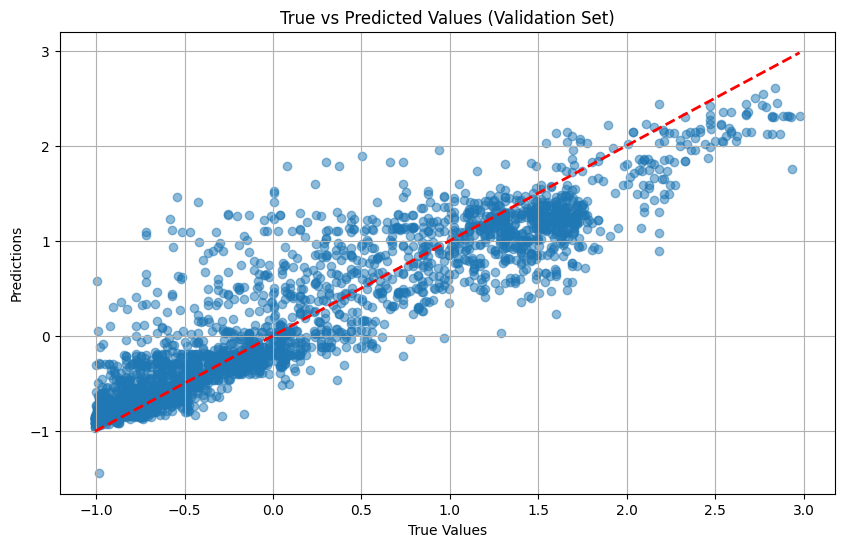

In [122]:
# График сравнения предсказаний с реальными значениями
plt.figure(figsize=(10, 6))
plt.scatter(y_val_np, y_pred, alpha=0.5)
plt.plot([y_val_np.min(), y_val_np.max()], [y_val_np.min(), y_val_np.max()], 'r--', lw=2)
plt.title('True vs Predicted Values (Validation Set)')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.grid(True)
plt.show()

### Обработка тестовых данных

In [126]:
test = pd.read_csv('test.csv')
formula_test = pd.read_csv("formula_test.csv")

test_full = pd.concat([test, formula_test], axis=1)
test_full.drop(columns=['material'], inplace=True)

train_columns = train_full.drop(columns=['critical_temp']).columns

X_val = test_full[train_columns].values.astype(np.float32)
X_norm = scaler_X.transform(X_val)
X_val_tensor = torch.tensor(X_norm, dtype=torch.float32)

model.eval()
with torch.no_grad():
    y_pred_val = model(X_val_tensor).cpu().detach().numpy().flatten()

y_pred = scaler_y.inverse_transform(y_pred_val.reshape(-1, 1)).flatten()

In [127]:
submit_index = range(len(y_pred_val))
submission = pd.DataFrame({
    "index": submit_index,
    "critical_temp": y_pred_val
})
submission.to_csv("submission.csv", index=False)